In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Union
import matplotlib
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
from pydub import AudioSegment
import pandas as pd
import soundfile as sf

In [3]:
DATASET_NAME = [
    # 'Pitt',
    'Pitt-origin',
    'ADReSS',
    'ADReSSo',
    'ADReSS-M']

BASE_DIR = Path('../ad_detection/data/raw')

In [4]:
def get_audio_duration(audio_path: str) -> float:
    if audio_path.endswith('.wav'):
        info = sf.info(audio_path)
        return info.duration
    else:  # mp3
        audio = AudioSegment.from_mp3(audio_path)
        return len(audio) / 1000.0


def analyze_dataset(dataset_path: Path):
    durations = []
    class_counts = {'Control': 0, 'Dementia': 0}
    
    for subdir in ['Control', 'Dementia']:
        subdir_path = dataset_path / subdir
        if not subdir_path.exists():
            print(f"  Warning: {subdir_path} does not exist, skipping.")
            continue
        for file_path in subdir_path.glob('*.[wm][ap][v3]'):
            durations.append(get_audio_duration(str(file_path)))
            class_counts[subdir] += 1
    
    return {'durations': durations, 'class_counts': class_counts}


def print_statistics(dataset_name: str, durations: List[float]):
    print(f"\n==============Dataset: {dataset_name}==============")
    print(f"File count: {len(durations)}")
    if not durations:
        print("  No audio files found!")
        return
    print(f"Max duration: {max(durations):.2f} sec")
    print(f"Min duration: {min(durations):.2f} sec")
    print(f"Mean duration: {np.mean(durations):.2f} sec")
    print(f"Median duration: {np.median(durations):.2f} sec")
    print(f"Total duration: {sum(durations)/60:.2f} min")

## 4. Analyze All Datasets

In [5]:
dataset_stats = {}

for name in DATASET_NAME:
    result = analyze_dataset(BASE_DIR / name)
    dataset_stats[name] = result
    print_statistics(name, result['durations'])


==============Dataset: Pitt-origin==============
File count: 552
Max duration: 268.49 sec
Min duration: 17.89 sec
Mean duration: 69.97 sec
Median duration: 63.20 sec
Total duration: 643.72 min

==============Dataset: ADReSS==============
File count: 156
Max duration: 268.48 sec
Min duration: 26.06 sec
Mean duration: 75.30 sec
Median duration: 70.05 sec
Total duration: 195.78 min

==============Dataset: ADReSSo==============
File count: 237
Max duration: 268.49 sec
Min duration: 22.35 sec
Mean duration: 76.89 sec
Median duration: 70.47 sec
Total duration: 303.72 min

==============Dataset: ADReSS-M==============
File count: 237
Max duration: 268.49 sec
Min duration: 22.29 sec
Mean duration: 76.89 sec
Median duration: 70.48 sec
Total duration: 303.72 min


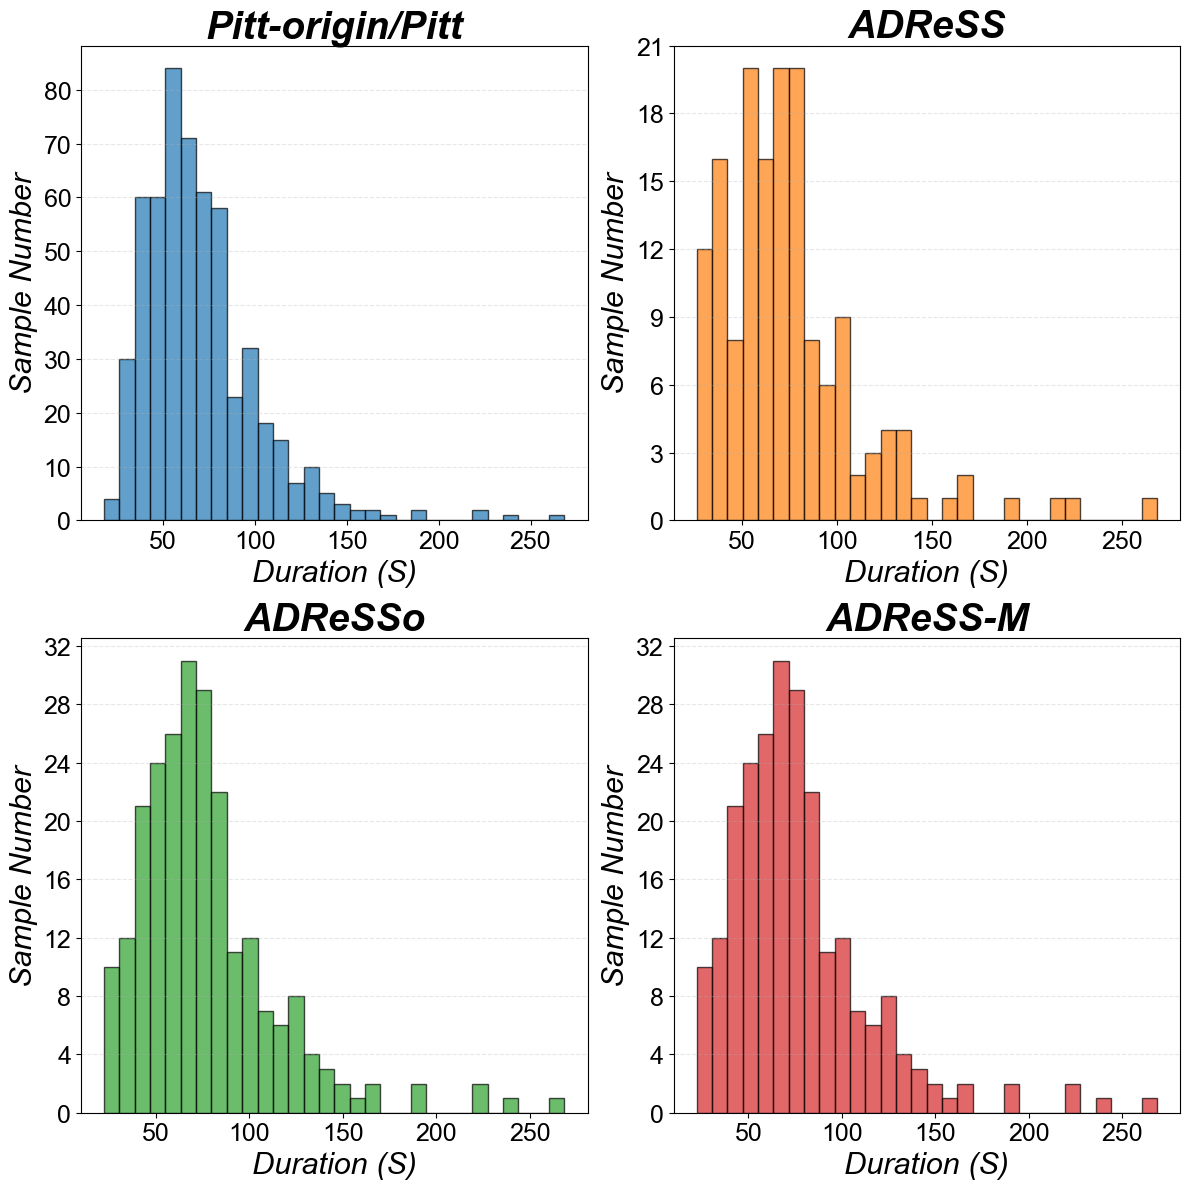

In [6]:
from matplotlib.ticker import MaxNLocator

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
plot_config = [
    ('Pitt-origin', 'Pitt-origin/Pitt'),
    ('ADReSS', 'ADReSS'),
    ('ADReSSo', 'ADReSSo'),
    ('ADReSS-M', 'ADReSS-M'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for idx, (name, title) in enumerate(plot_config):
    durations = dataset_stats[name]['durations']
    ax = axes[idx]
    
    ax.hist(durations, bins=30, color=COLORS[idx], alpha=0.7, edgecolor='black')
    
    ax.set_xlabel('Duration (S)', fontsize=22, fontstyle='italic')
    ax.set_ylabel('Sample Number', fontsize=22, fontstyle='italic')
    ax.set_title(title, fontsize=28, fontweight='bold', fontstyle='italic')
    ax.tick_params(axis='both', labelsize=18)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('duration_distribution.pdf', bbox_inches='tight')
plt.show()

## 6. Summary Statistics Table

In [7]:
summary_data = []
for name in DATASET_NAME:
    durations = dataset_stats[name]['durations']
    class_counts = dataset_stats[name]['class_counts']
    summary_data.append({
        'Dataset': name,
        'File Count': len(durations),
        'Dementia Count': class_counts['Dementia'],
        'Control Count': class_counts['Control'],
        'Min Duration (s)': f"{min(durations):.2f}",
        'Max Duration (s)': f"{max(durations):.2f}",
        'Mean Duration (s)': f"{np.mean(durations):.2f}",
        'Median Duration(s)': f"{np.median(durations):.2f}",
        'Total Duration (min)': f"{sum(durations)/60:.2f}"
    })

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("Summary Statistics for All Datasets")
print("="*100)
print(df_summary.to_string(index=False))

df_summary.to_csv('audio_duration_summary.csv', index=False, encoding='utf-8-sig')


Summary Statistics for All Datasets
    Dataset  File Count  Dementia Count  Control Count Min Duration (s) Max Duration (s) Mean Duration (s) Median Duration(s) Total Duration (min)
Pitt-origin         552             309            243            17.89           268.49             69.97              63.20               643.72
     ADReSS         156              78             78            26.06           268.48             75.30              70.05               195.78
    ADReSSo         237             122            115            22.35           268.49             76.89              70.47               303.72
   ADReSS-M         237             122            115            22.29           268.49             76.89              70.48               303.72
